In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

metrics = pd.read_csv('../data/processed/employee_metrics.csv')

# Create binary target: 1 = High Performer, 0 = Not
metrics['is_high_performer'] = (metrics['performance_tier'] == 'High Performer').astype(int)

# Select features
feature_cols = ['completion_rate', 'deadline_adherence_rate', 'avg_efficiency',
                'avg_satisfaction', 'time_efficiency_ratio', 'years_experience',
                'total_tasks_assigned', 'high_priority_tasks']

# Encode department as a feature
le = LabelEncoder()
metrics['dept_encoded'] = le.fit_transform(metrics['department'].fillna('Unknown'))
feature_cols.append('dept_encoded')

X = metrics[feature_cols].fillna(0)
y = metrics['is_high_performer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (160, 9), Test set: (40, 9)


In [2]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 97.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       0.00      0.00      0.00         1

    accuracy                           0.97        40
   macro avg       0.49      0.50      0.49        40
weighted avg       0.95      0.97      0.96        40



/Users/asadqasim/Documents/Projects/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/asadqasim/Documents/Projects/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/asadqasim/Documents/Projects/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

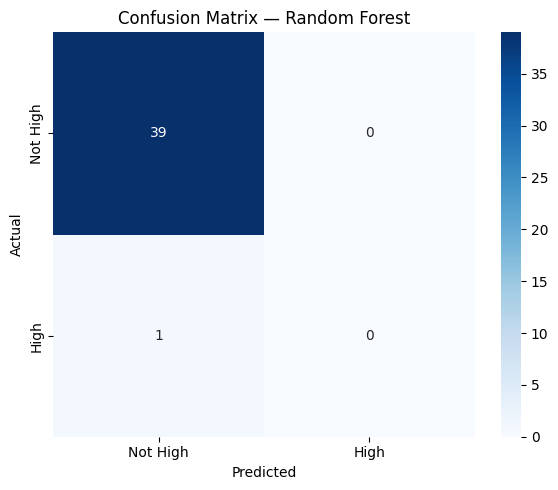

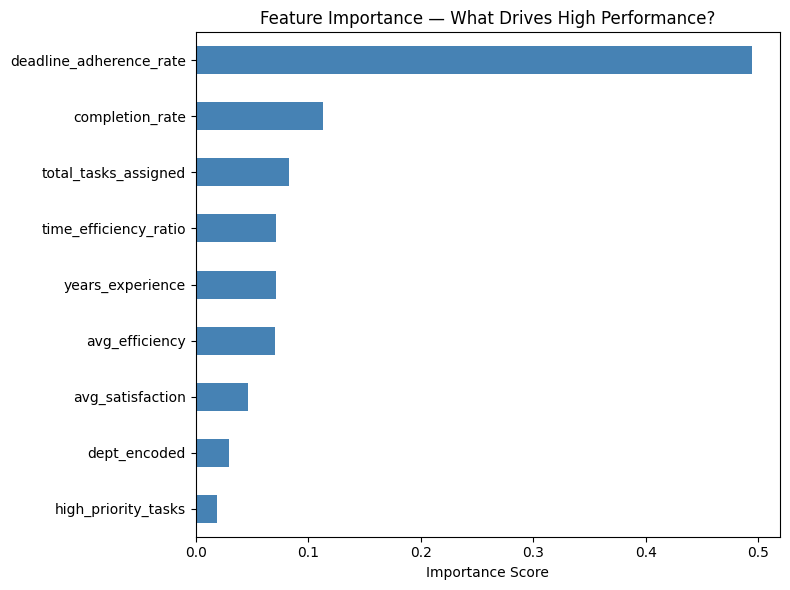

Model saved!


In [3]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'], yticklabels=['Not High', 'High'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What Drives High Performance?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

# Save model
import joblib
joblib.dump(rf_model, '../src/performance_model.pkl')
print("Model saved!")